In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project Root:", PROJECT_ROOT)

Project Root: g:\Projects\Dementia_Detection_Model


In [2]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

from src.models.cbam import (
    CBAM,
    ChannelAttention,
    SpatialAttention,
)

from src.dataset.loader import create_dataloaders
from src.config import model_config

In [6]:
from tensorflow.keras.models import load_model

MODEL_PATH = r"G:\Projects\Dementia_Detection_Model\saved_models\efficientnet_cbam.keras"

model = load_model(
    MODEL_PATH,
    custom_objects={
        "CBAM": CBAM,
        "ChannelAttention": ChannelAttention,
        "SpatialAttention": SpatialAttention,
    },
)

print("CBAM model loaded successfully!")

g:\Projects\Dementia_Detection_Model\venv\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'cbam', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



CBAM model loaded successfully!


In [7]:
model.summary()

Model: "EfficientNetV2B0_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam (CBAM)                     │ (None, 7, 7, 1280)     │       206,258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,553,460 (25.00 MB)

 Trainable params: 211,382 (825.71 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

 Optimizer params: 422,766 (1.61 MB)

In [8]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, type(layer).__name__, layer.trainable)

0 input_image InputLayer True
1 efficientnetv2-b0 Functional False
2 cbam CBAM True
3 global_average_pooling GlobalAveragePooling2D True
4 dropout Dropout True
5 classifier Dense True


In [9]:
backbone = model.get_layer("efficientnetv2-b0")

print("Backbone:", backbone.name)
print("Number of layers:", len(backbone.layers))

for i, layer in enumerate(backbone.layers):
    print(i, layer.name, type(layer).__name__, layer.trainable)

Backbone: efficientnetv2-b0
Number of layers: 270
0 input_image InputLayer True
1 rescaling Rescaling False
2 normalization Normalization False
3 stem_conv Conv2D False
4 stem_bn BatchNormalization False
5 stem_activation Activation False
6 block1a_project_conv Conv2D False
7 block1a_project_bn BatchNormalization False
8 block1a_project_activation Activation False
9 block2a_expand_conv Conv2D False
10 block2a_expand_bn BatchNormalization False
11 block2a_expand_activation Activation False
12 block2a_project_conv Conv2D False
13 block2a_project_bn BatchNormalization False
14 block2b_expand_conv Conv2D False
15 block2b_expand_bn BatchNormalization False
16 block2b_expand_activation Activation False
17 block2b_project_conv Conv2D False
18 block2b_project_bn BatchNormalization False
19 block2b_drop Dropout False
20 block2b_add Add False
21 block3a_expand_conv Conv2D False
22 block3a_expand_bn BatchNormalization False
23 block3a_expand_activation Activation False
24 block3a_project_conv Con

In [11]:
# Get the EfficientNetV2B0 backbone
backbone = model.get_layer("efficientnetv2-b0")

# First, freeze the entire backbone
backbone.trainable = False

# Unfreeze only the top 30 layers
for layer in backbone.layers[-30:]:
    layer.trainable = True

# Keep BatchNormalization layers frozen
# This helps preserve their learned statistics during fine-tuning.
for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

print("Fine-tuning configuration applied.")

Fine-tuning configuration applied.


In [12]:
for i, layer in enumerate(backbone.layers):
    if layer.trainable:
        print(i, layer.name, type(layer).__name__)

0 input_image InputLayer
240 block6g_dwconv2 DepthwiseConv2D
242 block6g_activation Activation
243 block6g_se_squeeze GlobalAveragePooling2D
244 block6g_se_reshape Reshape
245 block6g_se_reduce Conv2D
246 block6g_se_expand Conv2D
247 block6g_se_excite Multiply
248 block6g_project_conv Conv2D
250 block6g_drop Dropout
251 block6g_add Add
252 block6h_expand_conv Conv2D
254 block6h_expand_activation Activation
255 block6h_dwconv2 DepthwiseConv2D
257 block6h_activation Activation
258 block6h_se_squeeze GlobalAveragePooling2D
259 block6h_se_reshape Reshape
260 block6h_se_reduce Conv2D
261 block6h_se_expand Conv2D
262 block6h_se_excite Multiply
263 block6h_project_conv Conv2D
265 block6h_drop Dropout
266 block6h_add Add
267 top_conv Conv2D
269 top_activation Activation


In [13]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [14]:
model.summary()

Model: "EfficientNetV2B0_CBAM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam (CBAM)                     │ (None, 7, 7, 1280)     │       206,258 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,130,694 (23.39 MB)

 Trainable params: 1,365,014 (5.21 MB)

 Non-trainable params: 4,765,680 (18.18 MB)

In [15]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

checkpoint = ModelCheckpoint(
    "saved_models/efficientnet_cbam_finetuned.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [16]:
import inspect
from src.dataset.loader import create_dataloaders

print(inspect.signature(create_dataloaders))

() -> tuple[tensorflow.python.data.ops.dataset_ops.DatasetV2, tensorflow.python.data.ops.dataset_ops.DatasetV2, tensorflow.python.data.ops.dataset_ops.DatasetV2]


In [20]:
from pathlib import Path
import os

PROJECT_ROOT = Path(r"G:\Projects\Dementia_Detection_Model")

os.chdir(PROJECT_ROOT)

print("Current working directory:")
print(Path.cwd())

Current working directory:
G:\Projects\Dementia_Detection_Model


In [21]:
from pathlib import Path

print(
    Path("data/processed/train.csv").exists()
)

print(
    Path("data/processed/validation.csv").exists()
)

print(
    Path("data/processed/test.csv").exists()
)

True
True
True


In [22]:
train_dataset, val_dataset, test_dataset = create_dataloaders()

print("Datasets created successfully!")

Datasets created successfully!


In [23]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled successfully.")

Model recompiled successfully.


In [26]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Labels:", labels[:10].numpy())

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Labels: [2 1 3 0 1 3 2 0 1 2]


In [27]:
history_ft = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[
        checkpoint,
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8227 - loss: 0.4142
Epoch 1: val_accuracy improved from None to 0.87875, saving model to saved_models/efficientnet_cbam_finetuned.keras

Epoch 1: finished saving model to saved_models/efficientnet_cbam_finetuned.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1625s 2s/step - accuracy: 0.8227 - loss: 0.4142 - val_accuracy: 0.8788 - val_loss: 0.3006 - learning_rate: 1.0000e-05
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8313 - loss: 0.3965
Epoch 2: val_accuracy improved from 0.87875 to 0.88325, saving model to saved_models/efficientnet_cbam_finetuned.keras

Epoch 2: finished saving model to saved_models/efficientnet_cbam_finetuned.keras
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2036s 2s/step - accuracy: 0.8313 - loss: 0.3965 - val_accuracy: 0.8832 - val_loss: 0.2904 - learning_rate: 1.0000e-05
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8391 - loss: 0.3820
Epoch 3: val_accuracy improved from 0.8832

In [28]:
from tensorflow.keras.models import load_model

FINETUNED_MODEL_PATH = r"G:\Projects\Dementia_Detection_Model\saved_models\efficientnet_cbam_finetuned.keras"

finetuned_model = load_model(
    FINETUNED_MODEL_PATH,
    custom_objects={
        "CBAM": CBAM,
        "ChannelAttention": ChannelAttention,
        "SpatialAttention": SpatialAttention,
    }
)

print("Fine-tuned model loaded successfully!")

g:\Projects\Dementia_Detection_Model\venv\Lib\site-packages\keras\src\layers\layer.py:431: UserWarning: `build()` was called on layer 'cbam', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Fine-tuned model loaded successfully!


In [29]:
test_loss, test_accuracy = finetuned_model.evaluate(
    test_dataset,
    verbose=1
)

print(f"Fine-tuned Test Loss: {test_loss:.4f}")
print(f"Fine-tuned Test Accuracy: {test_accuracy:.4f}")
print(f"Fine-tuned Test Accuracy: {test_accuracy * 100:.2f}%")

125/125 ━━━━━━━━━━━━━━━━━━━━ 106s 806ms/step - accuracy: 0.8982 - loss: 0.2524
Fine-tuned Test Loss: 0.2524
Fine-tuned Test Accuracy: 0.8982
Fine-tuned Test Accuracy: 89.82%


In [30]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = finetuned_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels:", y_true.shape)
print("Predictions:", y_pred.shape)

True labels: (4000,)
Predictions: (4000,)


In [31]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df.round(4))

                  precision  recall  f1-score    support
NonDemented          0.9018  0.9730    0.9360  1000.0000
VeryMildDemented     0.9970  1.0000    0.9985  1000.0000
MildDemented         0.8823  0.7720    0.8235  1000.0000
ModerateDemented     0.8130  0.8480    0.8302  1000.0000
accuracy             0.8982  0.8982    0.8982     0.8982
macro avg            0.8985  0.8982    0.8970  4000.0000
weighted avg         0.8985  0.8982    0.8970  4000.0000


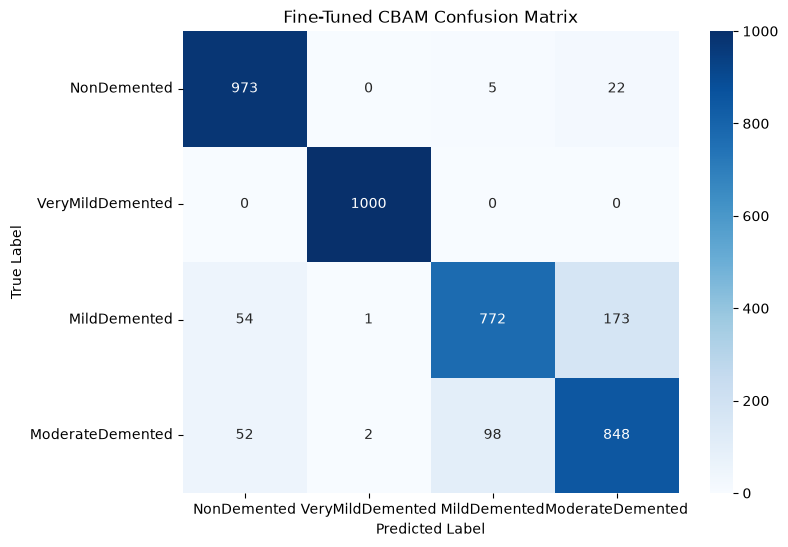

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_names = [
    "NonDemented",
    "VeryMildDemented",
    "MildDemented",
    "ModerateDemented"
]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Fine-Tuned CBAM Confusion Matrix")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    "Original CBAM": [
        0.3463,
        0.8568,
        None,
        None,
        None
    ],
    "Fine-Tuned CBAM": [
        test_loss,
        test_accuracy,
        report["macro avg"]["precision"],
        report["macro avg"]["recall"],
        report["macro avg"]["f1-score"]
    ]
})

comparison